<div style=" background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 4 DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Réalisez une étude de santé publique avec R ou Python
</h2>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [2]:
#Importation de la librairie Pandas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
# Config
sns.set_theme(
    palette='Set2'
)

plt.rcParams.update({
    "font.family": "Trebuchet MS",
    "font.weight": "bold",
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

def makeBarplot(data, x, xLabel, y, yLabel, title, bar_label_format="%g", palette='Spectral'):
    plt.figure(figsize=(10, 6))
    graph = sns.barplot(data=data, x=x, y=y, palette=palette)

    # make labels for each bar
    for i in graph.containers:
        graph.bar_label(i, fmt=bar_label_format, padding=5)
    
    makeGraphAttribut(
        graph=graph, 
        xLabel=xLabel, 
        yLabel=yLabel, 
        title=title
    )
    return graph

def makeGraphAttribut(graph,  xLabel, yLabel, title):
    graph.set_xlabel(xLabel, fontweight='bold', fontsize=12)
    graph.set_ylabel(yLabel, fontweight='bold', fontsize=12)
    graph.set_title(title, fontweight='bold', fontsize=15, pad=20)

## Make title with plt
def makeTitle(title):
    plt.title(
        title,
        fontsize=15,
        fontweight="bold",
        pad=20
    )

def makeYlabel(text):
    plt.ylabel(ylabel=text, fontweight='bold', fontsize=12)

# Make percentage text label in pie chart
def makePctLabel(pct_texts, colour='white'):
    for pct in pct_texts:
        pct.set_color(colour)
        pct.set_fontweight('bold')


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers Excel</h3>
</div>

In [4]:
#Importation du fichier population.csv
population = pd.read_csv('files/population.csv')

#Importation du fichier dispo_alimentaire.csv
dispo_alimentaire = pd.read_csv('files/dispo_alimentaire.csv')

#Importation du fichier aide_alimentaire.csv
aide_alimentaire = pd.read_csv('files/aide_alimentaire.csv')

#Importation du fichier sous_nutrition.csv
sous_nutrition = pd.read_csv('files/sous_nutrition.csv')

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier population</h3>
</div>

In [5]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(population.shape[0]))
print("Le tableau comporte {} colonne(s)".format(population.shape[1]))

Le tableau comporte 1416 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [6]:
#Consulter le nombre de colonnes
population.shape[1]

#La nature des données dans chacune des colonnes
population.dtypes

#Le nombre de valeurs présentes dans chacune des colonnes
population.count()

Zone      1416
Année     1416
Valeur    1416
dtype: int64

In [7]:
#Affichage les 5 premières lignes de la table
population.head()

,Zone,Année,Valeur
0,Afghanistan,2013,32269.589
1,Afghanistan,2014,33370.794
2,Afghanistan,2015,34413.603
3,Afghanistan,2016,35383.032
4,Afghanistan,2017,36296.113


In [8]:
#Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000
#Multiplication de la colonne valeur par 1000
population.Valeur *= 1000

In [9]:
#changement du nom de la colonne Valeur par Population
population = population.rename(columns={'Valeur': 'Population'})

In [10]:
#Affichage les 5 premières lignes de la table pour voir les modifications
population.head()

,Zone,Année,Population
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

In [11]:
#Afficher les dimensions du dataset
print(f"Le tableau comporte {dispo_alimentaire.shape[0]} observation(s)")
print(f"Le tableau comporte {dispo_alimentaire.shape[1]} colonne(s)")

Le tableau comporte 15605 observation(s)
Le tableau comporte 18 colonne(s)


In [12]:
#Consulter le nombre de colonnes
dispo_alimentaire.shape[1]

18

In [13]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


In [14]:
#remplacement des NaN dans le dataset par des 0
dispo_alimentaire = dispo_alimentaire.fillna(0)

In [15]:
#multiplication de toutes les lignes contenant des milliers de tonnes en Kg
milliers_cols = dispo_alimentaire.columns[3:5].union(dispo_alimentaire.columns[9:-1])

dispo_alimentaire[milliers_cols] = dispo_alimentaire[milliers_cols] * 1000000

In [16]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

In [17]:
#Afficher les dimensions du dataset
print(f"Le tableau comporte {aide_alimentaire.shape[0]} observation(s)")
print(f"Le tableau comporte {aide_alimentaire.shape[1]} colonne(s)")

Le tableau comporte 1475 observation(s)
Le tableau comporte 4 colonne(s)


In [18]:
#Consulter le nombre de colonnes
aide_alimentaire.shape[1]

4

In [19]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head()

,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


In [20]:
#changement du nom de la colonne Pays bénéficiaire par Zone
aide_alimentaire = aide_alimentaire.rename(columns={'Pays bénéficiaire': 'Zone'})

In [21]:
#Multiplication de la colonne Aide_alimentaire qui contient des tonnes par 1000 pour avoir des kg
aide_alimentaire.Valeur *= 1000

In [22]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head()

,Zone,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

In [23]:
#Afficher les dimensions du dataset
print(f"Le tableau comporte {sous_nutrition.shape[0]} observation(s)")
print(f"Le tableau comporte {sous_nutrition.shape[1]} colonne(s)")

Le tableau comporte 1218 observation(s)
Le tableau comporte 3 colonne(s)


In [24]:
#Consulter le nombre de colonnes
sous_nutrition.shape[1]

3

In [25]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head()

,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [26]:
#Conversion de la colonne sous nutrition en numérique
# sous_nutrition['Valeur'] = pd.to_numeric(sous_nutrition['Valeur'])

In [27]:
#Conversion de la colonne (avec l'argument errors=coerce qui permet de convertir automatiquement les lignes qui ne sont pas des nombres en NaN)
#Puis remplacement des NaN en 0
sous_nutrition['Valeur'] = pd.to_numeric(sous_nutrition['Valeur'], errors='coerce')
sous_nutrition['Valeur'] = sous_nutrition['Valeur'].fillna(0)

In [28]:
#changement du nom de la colonne Valeur par sous_nutrition
sous_nutrition = sous_nutrition.rename(columns={'Valeur': 'sous_nutrition'})

In [29]:
#Multiplication de la colonne sous_nutrition par 1000000
sous_nutrition.sous_nutrition *= 1000000

In [30]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head()

,Zone,Année,sous_nutrition
0,Afghanistan,2012-2014,8600000.0
1,Afghanistan,2013-2015,8800000.0
2,Afghanistan,2014-2016,8900000.0
3,Afghanistan,2015-2017,9700000.0
4,Afghanistan,2016-2018,10500000.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1 - Proportion de personnes en sous nutrition</h3>
</div>

In [31]:
# Il faut tout d'abord faire une jointure entre la table population et la table sous nutrition, en ciblant l'année 2017
population_2017 = population.loc[population.Année == 2017]

sous_nutrition_2017 = sous_nutrition.copy()
sous_nutrition_2017[['debut_annee', 'fin_annee']] = sous_nutrition.Année.str.split('-', expand=True).astype(int)

sous_nutrition_2017 = sous_nutrition_2017.loc[
    (sous_nutrition_2017.debut_annee + sous_nutrition_2017.fin_annee) / 2 == 2017
]

population_sous_nutrition_2017 = pd.merge(population_2017, sous_nutrition_2017, on='Zone', how='inner')

In [32]:
#Affichage du dataset
population_sous_nutrition_2017.head()

,Zone,Année_x,Population,Année_y,sous_nutrition,debut_annee,fin_annee
0,Afghanistan,2017,36296113.0,2016-2018,10500000.0,2016,2018
1,Afrique du Sud,2017,57009756.0,2016-2018,3100000.0,2016,2018
2,Albanie,2017,2884169.0,2016-2018,100000.0,2016,2018
3,Algérie,2017,41389189.0,2016-2018,1300000.0,2016,2018
4,Allemagne,2017,82658409.0,2016-2018,0.0,2016,2018


In [33]:
# proportion de sous-nutrition mondialement
population_sous_nutrition_2017_mondialement = population_sous_nutrition_2017.groupby('Année_x')[['Population', 'sous_nutrition']].sum()
population_sous_nutrition_2017_mondialement['proportion'] = population_sous_nutrition_2017_mondialement['sous_nutrition'] / population_sous_nutrition_2017_mondialement['Population']

total_sous_nutrition_2017 = population_sous_nutrition_2017_mondialement['sous_nutrition'].iloc[0]
total_sous_nutrition_2017

np.float64(535700000.0)

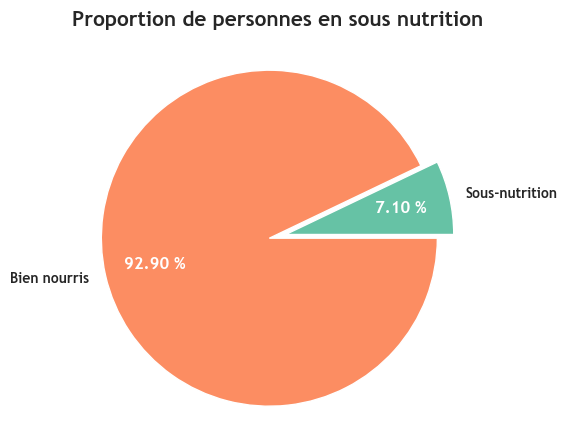

In [34]:
# graphique : proportion de sous-nutrition mondialement

explode = (0.05, 0.05)

widget, label, pct = plt.pie(
    [population_sous_nutrition_2017_mondialement['sous_nutrition'].iloc[0], (population_sous_nutrition_2017_mondialement['Population'] - population_sous_nutrition_2017_mondialement['sous_nutrition']).iloc[0]],
    labels=['Sous-nutrition', 'Bien nourris'],
    autopct="%.2f %%",
    pctdistance=0.7,
    explode=explode
)

makeTitle('Proportion de personnes en sous nutrition')
makePctLabel(pct)
plt.axis('equal')
plt.show()

In [35]:
#Calcul et affichage du nombre de personnes en état de sous nutrition (top 10 pays)
population_sous_nutrition_2017['proportion_sous_nutrition'] = (
    (population_sous_nutrition_2017.sous_nutrition / population_sous_nutrition_2017.Population * 100).round(2)
)
population_sous_nutrition_2017['proportion_sous_nutrition_str'] = population_sous_nutrition_2017['proportion_sous_nutrition'].map(lambda x: f"{x: .2f} %")
population_sous_nutrition_2017['sous_nutrition'] = population_sous_nutrition_2017['sous_nutrition'].astype(int)

population_sous_nutrition_2017.sort_values(
    'proportion_sous_nutrition', ascending=False
)[['Zone', 'sous_nutrition', 'proportion_sous_nutrition_str']].head(10)

,Zone,sous_nutrition,proportion_sous_nutrition_str
78,Haïti,5300000,48.26 %
157,République populaire démocratique de Corée,12000000,47.19 %
108,Madagascar,10500000,41.06 %
103,Libéria,1800000,38.28 %
100,Lesotho,800000,38.25 %
183,Tchad,5700000,37.96 %
161,Rwanda,4200000,35.06 %
121,Mozambique,9400000,32.81 %
186,Timor-Leste,400000,32.17 %
0,Afghanistan,10500000,28.93 %


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2 - Nombre théorique de personne qui pourrait être nourries</h3>
</div>

In [36]:
#Combien mange en moyenne un être humain ? Source => population et dispo_alimentaire

In [37]:
#On commence par faire une jointure entre le data frame population et Dispo_alimentaire afin d'ajouter dans ce dernier la population
population_dispo_alimentaire = pd.merge(dispo_alimentaire, population_2017, on='Zone', how='left')

In [38]:
#Affichage du nouveau dataframe
population_dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Année,Population
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0,2017.0,36296113.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0,2017.0,36296113.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,2017.0,36296113.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017.0,36296113.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0,2017.0,36296113.0


In [39]:
#Création de la colonne dispo_kcal avec calcul des kcal disponibles mondialement
population_dispo_alimentaire['dispo_kcal'] = (
    population_dispo_alimentaire['Disponibilité alimentaire (Kcal/personne/jour)'] * population_dispo_alimentaire['Population']
)
total_kcal_mondialement = population_dispo_alimentaire['dispo_kcal'].sum()

In [40]:
#Calcul du nombre d'humains pouvant être nourris

# Standard kcal requirement per person/day
kcal_par_personne_par_jour = 2100

nombre_humains_nourris = total_kcal_mondialement / kcal_par_personne_par_jour
population_totale_2017 = population_2017['Population'].sum()

print(f'Population totale: {int(population_totale_2017)}')
print(f"Nombre d'humains pouvant être nourris: {int(nombre_humains_nourris)}")


Population totale: 7548134111
Nombre d'humains pouvant être nourris: 9961421251


/var/folders/l2/wxdjr68x4hjf3wqj0ww37d9r0000gn/T/ipykernel_16305/1804943040.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  graph = sns.barplot(data=data, x=x, y=y, palette=palette)


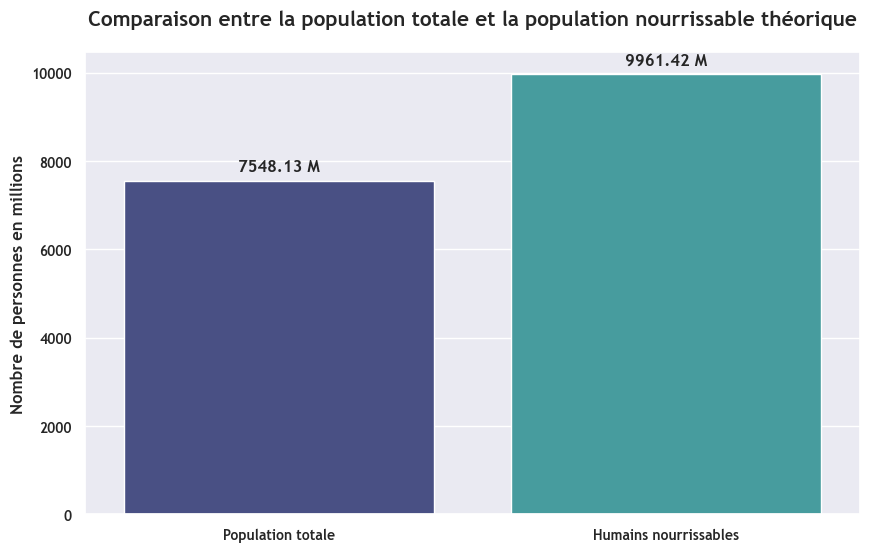

In [41]:
# graphique
personnes_nourrissables = pd.DataFrame()

personnes_nourrissables['categorie'] = ['Population totale', 'Humains nourrissables']
personnes_nourrissables['value'] = [population_totale_2017, nombre_humains_nourris]
personnes_nourrissables['value_million'] = personnes_nourrissables['value'] / 1e6

# diff in percentage
personnes_nourrissables_diff = ((personnes_nourrissables['value'][1] - personnes_nourrissables['value'][0]) / personnes_nourrissables['value'][0] * 100).round(2)

makeBarplot(
    personnes_nourrissables,
    x='categorie',
    xLabel='',
    y='value_million',
    yLabel='Nombre de personnes en millions',
    title='Comparaison entre la population totale et la population nourrissable théorique',
    bar_label_format="%.2f M",
    palette='mako'
)
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3 - Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux</h3>
</div>

In [42]:
#Transfert des données avec les végétaux dans un nouveau dataframe
dispo_vegetaux = population_dispo_alimentaire.loc[population_dispo_alimentaire['Origine'] == 'vegetale']

In [43]:
#Calcul du nombre de kcal disponible pour les végétaux
totale_kcal_vegetaux = dispo_vegetaux.dispo_kcal.sum()

In [44]:
#Calcul du nombre d'humains pouvant être nourris avec les végétaux
nombre_humains_nourris_vegetaux = totale_kcal_vegetaux / kcal_par_personne_par_jour

print(f"Nombre d'humains pouvant être nourris: {int(nombre_humains_nourris_vegetaux)}")

Nombre d'humains pouvant être nourris: 8219411529


/var/folders/l2/wxdjr68x4hjf3wqj0ww37d9r0000gn/T/ipykernel_16305/1804943040.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  graph = sns.barplot(data=data, x=x, y=y, palette=palette)


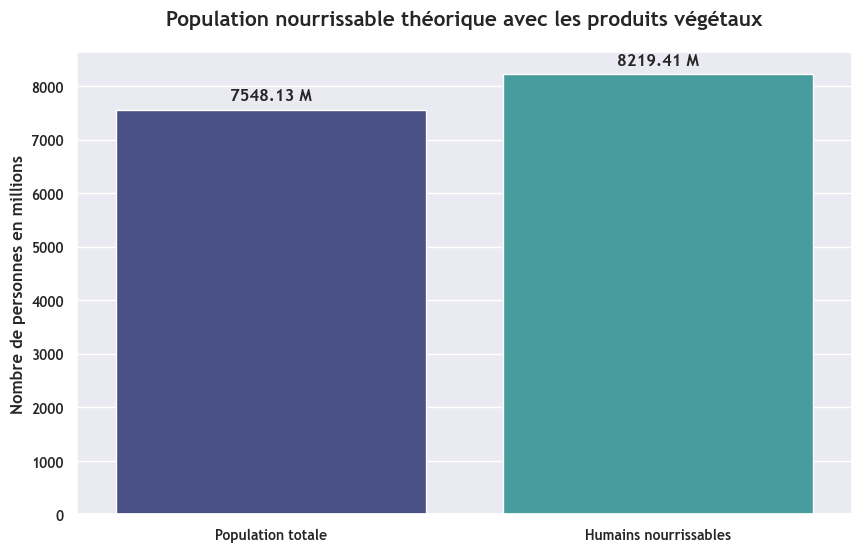

In [98]:
# graphique
personnes_nourrissables_veg = pd.DataFrame()

personnes_nourrissables_veg['categorie'] = ['Population totale', 'Humains nourrissables']
personnes_nourrissables_veg['value'] = [population_totale_2017, nombre_humains_nourris_vegetaux]
personnes_nourrissables_veg['value_million'] = personnes_nourrissables_veg['value'] / 1e6

# diff in percentage
personnes_nourrissables_veg_diff = ((personnes_nourrissables_veg['value'][1] - personnes_nourrissables_veg['value'][0]) / personnes_nourrissables_veg['value'][0] * 100).round(2)

makeBarplot(
    personnes_nourrissables_veg,
    x='categorie',
    xLabel='',
    y='value_million',
    yLabel='Nombre de personnes en millions',
    title='Population nourrissable théorique avec les produits végétaux',
    bar_label_format="%.2f M",
    palette='mako'
)
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4 - Utilisation de la disponibilité intérieure</h3>
</div>

In [46]:
#Calcul de la disponibilité totale
dispo_totale = dispo_alimentaire['Disponibilité intérieure'].sum()

In [47]:
#création d'une boucle for pour afficher les différentes valeurs en fonction des colonnes aliments pour animaux, pertes, nourritures, 
cols_utilisees = ['Aliments pour animaux', 'Nourriture', 'Pertes', 'Semences', 'Traitement', 'Autres Utilisations']
liste_valeur = []

for i in cols_utilisees:
    valeur = dispo_alimentaire[i].sum()
    liste_valeur.append(valeur)
    print(f"Disponibilité totale {i}: {valeur} kg, {round(valeur / dispo_totale *100, 2)} %")

Disponibilité totale Aliments pour animaux: 1304245000000.0 kg, 13.24 %
Disponibilité totale Nourriture: 4876258000000.0 kg, 49.51 %
Disponibilité totale Pertes: 453698000000.0 kg, 4.61 %
Disponibilité totale Semences: 154681000000.0 kg, 1.57 %
Disponibilité totale Traitement: 2204687000000.0 kg, 22.38 %
Disponibilité totale Autres Utilisations: 865023000000.0 kg, 8.78 %


(np.float64(-1.1243523201669499),
 np.float64(1.1314017064700703),
 np.float64(-1.1309455060794589),
 np.float64(1.1230445144171215))

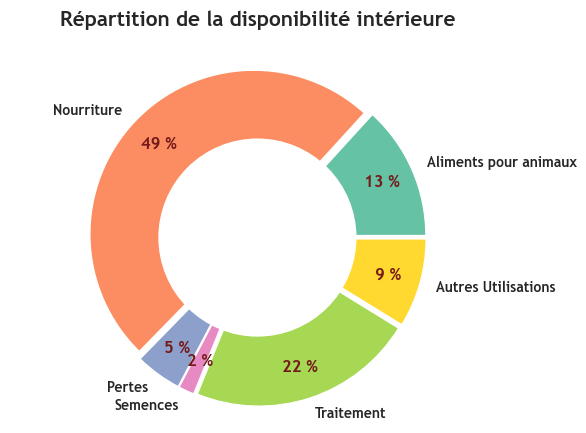

In [ ]:
# graphique

explode = tuple(np.full(len(liste_valeur), 0.03))
w, l, pct = plt.pie(
    liste_valeur, 
    labels=cols_utilisees, 
    autopct="%.0f %%",
    pctdistance=0.8,
    explode=explode
)
makeTitle("Répartition de la disponibilité intérieure")

# draw circle
centre_circle = plt.Circle((0, 0), 0.60, fc='white')
fig = plt.gcf()

# Adding Circle in Pie chart
fig.gca().add_artist(centre_circle)

makePctLabel(pct, colour="#751a1a")
plt.axis('equal')
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5 - Utilisation des céréales</h3>
</div>

In [49]:
#Création d'une liste avec toutes les variables
cols_cereales = ['Blé', 'Riz (Eq Blanchi)', 'Orge', 'Maïs', 'Seigle', 'Avoine', 'Millet', 'Sorgho', 'Céréales, Autres']

In [50]:
#Création d'un dataframe avec les informations uniquement pour ces céréales
dispo_cereales = dispo_alimentaire.loc[dispo_alimentaire['Produit'].isin(cols_cereales)]

In [51]:
#Affichage de la proportion d'alimentation animale
total_cereales = dispo_cereales['Disponibilité intérieure'].sum()
total_cereales_animaux = dispo_cereales['Aliments pour animaux'].sum()

print(f"La proportion d'alimentation animale: {round(total_cereales_animaux / total_cereales * 100, 2)} %")

La proportion d'alimentation animale: 36.29 %


In [52]:
#Affichage de la proportion d'alimentation humain (nourriture)
dispo_cereales_humain = dispo_cereales.Nourriture.sum()

print(f"La proportion d'alimentation humain (nourriture): {round(dispo_cereales_humain / total_cereales * 100, 2)} %")

La proportion d'alimentation humain (nourriture): 42.75 %


In [53]:
# Distribution of cereals for [Aliments pour animaux, Nourriture, Autre usage]
part_dispo_cereales = dispo_cereales.copy()
cols_cereales_3parts = ['Nourriture', 'Aliments pour animaux', 'Autres usages']

part_dispo_cereales['Autres usages'] = (
    part_dispo_cereales['Pertes']
    + part_dispo_cereales['Semences']
    + part_dispo_cereales['Traitement']
    + part_dispo_cereales['Autres Utilisations']
)

part_dispo_cereales = part_dispo_cereales.groupby('Produit')[cols_cereales_3parts].sum()

part_dispo_cereales[cols_cereales_3parts] /= 1e6
part_dispo_cereales['total'] = (
    part_dispo_cereales['Aliments pour animaux']
    + part_dispo_cereales['Nourriture']
    + part_dispo_cereales['Autres usages']
)
part_dispo_cereales['percentage_nourriture'] = part_dispo_cereales['Nourriture'] / part_dispo_cereales['total'] * 100
part_dispo_cereales

,Nourriture,Aliments pour animaux,Autres usages,total,percentage_nourriture
Produit,,,,,
Avoine,3903.0,16251.0,3241.0,23395.0,16.683052
Blé,457824.0,129668.0,92114.0,679606.0,67.366092
"Céréales, Autres",5324.0,19035.0,3536.0,27895.0,19.085858
Maïs,125184.0,546116.0,284572.0,955872.0,13.096314
Millet,23040.0,3306.0,3557.0,29903.0,77.049126
Orge,6794.0,92658.0,40996.0,140448.0,4.837378
Riz (Eq Blanchi),377286.0,33594.0,64776.0,475656.0,79.319088
Seigle,5502.0,8099.0,2964.0,16565.0,33.214609
Sorgho,24153.0,24808.0,9278.0,58239.0,41.472209


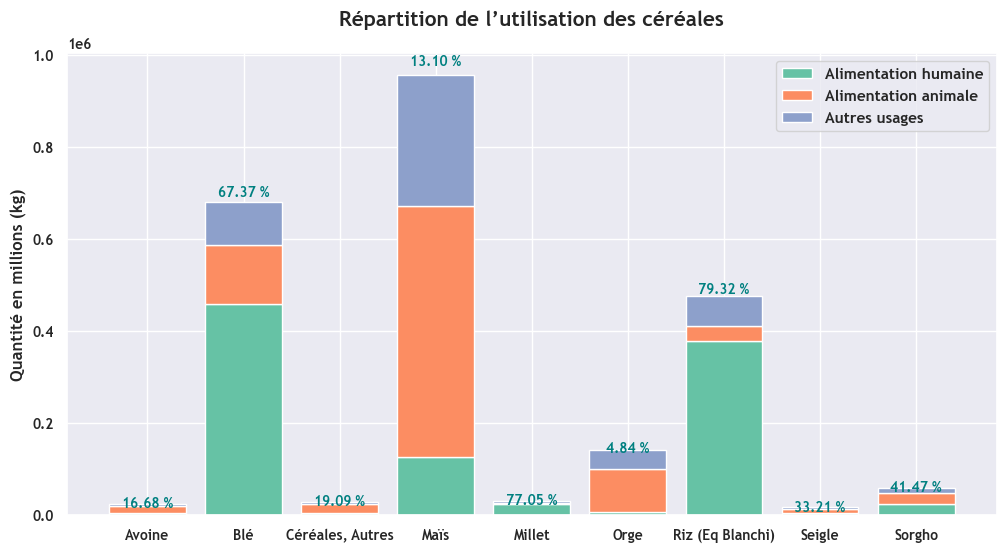

In [54]:
# graphique
fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    part_dispo_cereales.index,
    part_dispo_cereales['Nourriture'],
    label='Alimentation humaine'
)

ax.bar(
    part_dispo_cereales.index,
    part_dispo_cereales['Aliments pour animaux'],
    bottom=part_dispo_cereales['Nourriture'],
    label='Alimentation animale'
)

ax.bar(
    part_dispo_cereales.index,
    part_dispo_cereales['Autres usages'],
    bottom=(
        part_dispo_cereales['Nourriture']
        + part_dispo_cereales['Aliments pour animaux']
    ),
    label='Autres usages'
)

makeTitle("Répartition de l’utilisation des céréales")
ax.set_ylabel("Quantité en millions (kg)", fontweight='bold', fontsize=12)
ax.legend()
sns.set_palette('Set2')

# make labels
for i, produit in enumerate(part_dispo_cereales.index):
    y_position = (
        part_dispo_cereales.loc[produit, 'total'] * 1.03
    )

    ax.text(
        i,
        y_position,
        f"{part_dispo_cereales.loc[produit, 'percentage_nourriture']:.2f} %",
        ha='center',
        va='center',
        color='teal',
        fontweight='bold',
        fontsize=10
    )
plt.show()

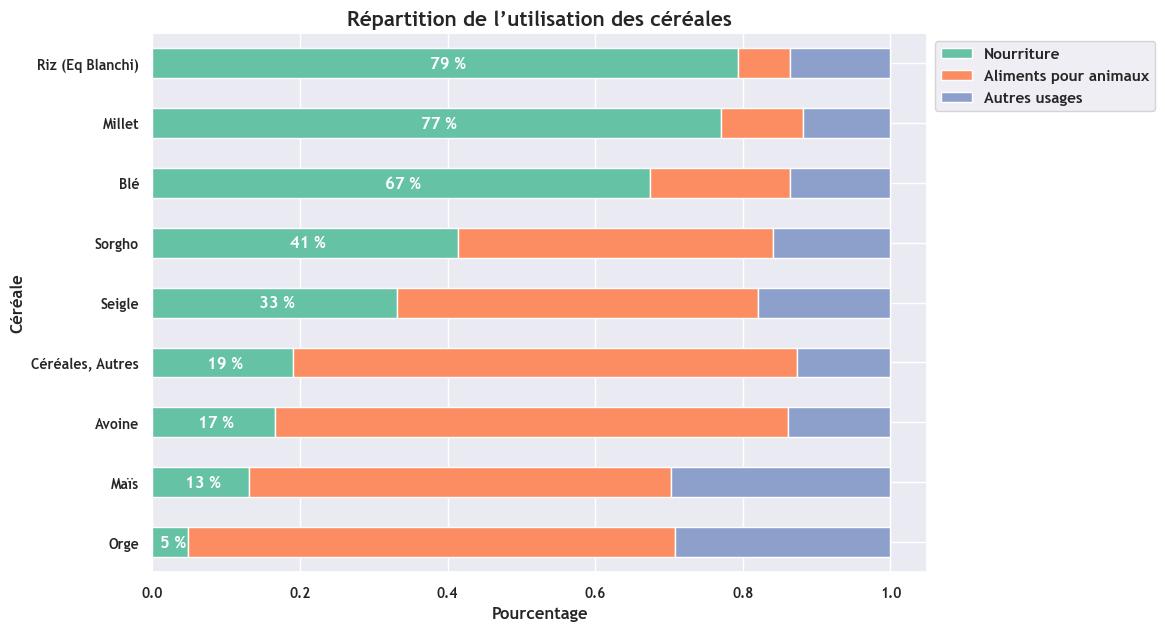

In [55]:
# another method
df_plot_sorted = part_dispo_cereales.sort_values(by='percentage_nourriture', ascending=True)
df_plot = df_plot_sorted[cols_cereales_3parts]
df_plot_pct = df_plot.div(df_plot.sum(axis=1), axis=0)  # normalize per row

ax = df_plot_pct.plot(
    kind='barh', 
    stacked=True, 
    xlabel="Pourcentage", 
    ylabel="Céréale", 
    title="Répartition de l’utilisation des céréales",
    figsize=(10, 7)
)

for index, value in enumerate(df_plot_sorted['percentage_nourriture']):
    ax.text(
        x=value*0.005,
        y=index,
        s=f"{value: .0f} %",
        va='center', 
        ha='center',
        color='white',
        fontweight='bold'
    )

plt.legend(loc='best', bbox_to_anchor=(1, 1))
plt.show()

(np.float64(-1.1170691847821563),
 np.float64(1.1173777859917475),
 np.float64(-1.114234732400972),
 np.float64(1.1210791254280208))

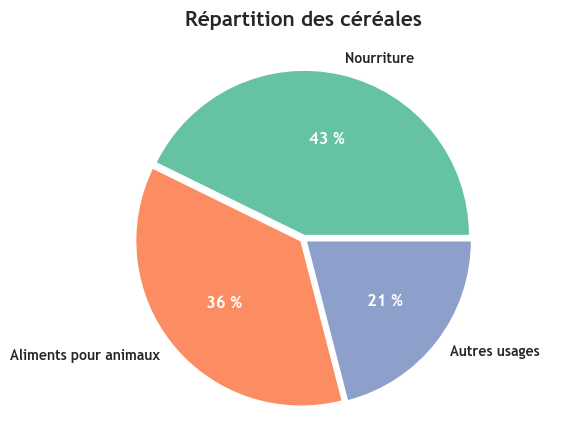

In [ ]:
total_graph_cereales = []
explode = tuple(np.full(len(cols_cereales_3parts), 0.02))

for i in cols_cereales_3parts:
    total_graph_cereales.append(part_dispo_cereales[i].sum())


w, l, pct = plt.pie(
    total_graph_cereales, 
    labels=cols_cereales_3parts, 
    autopct="%.0f %%", 
    pctdistance=0.6,
    explode=explode
)

makeTitle('Répartition des céréales')
makePctLabel(pct)
plt.axis('equal')
plt.show()

(np.float64(-1.1489238930537358),
 np.float64(1.1522715533159906),
 np.float64(-1.1265443916675477),
 np.float64(1.148854168183001))

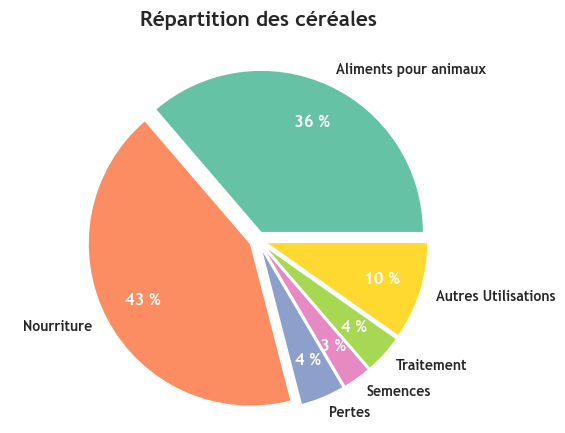

In [ ]:
# Distribution of cereals for all usages
proportion_cereales = []
explode = tuple(np.full(len(cols_utilisees), 0.05))

for i in cols_utilisees:
    valeur = dispo_cereales[i].sum()
    proportion_cereales.append(valeur)

wedge, label, pct = plt.pie(
    proportion_cereales, 
    labels=cols_utilisees, 
    autopct="%.0f %%", 
    pctdistance=0.75,
    explode=explode
)
sns.set_palette('Set2')
makeTitle('Répartition des céréales')
makePctLabel(pct)
plt.axis('equal')
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6 - Pays avec la proportion de personnes sous-alimentée la plus forte en 2017</h3>
</div>

In [58]:
#Création de la colonne proportion par pays
population_sous_nutrition_2017 = population_sous_nutrition_2017.rename(columns={'proportion_sous_nutrition': 'proportion'})
pays_sous_nutrition_2017 = population_sous_nutrition_2017[['Zone', 'proportion']]

In [59]:
#affichage après trie des 10 pires pays
sous_nutrition_plus_forte = pays_sous_nutrition_2017.sort_values('proportion', ascending=False).head(10)

/var/folders/l2/wxdjr68x4hjf3wqj0ww37d9r0000gn/T/ipykernel_16305/1804943040.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  graph = sns.barplot(data=data, x=x, y=y, palette=palette)


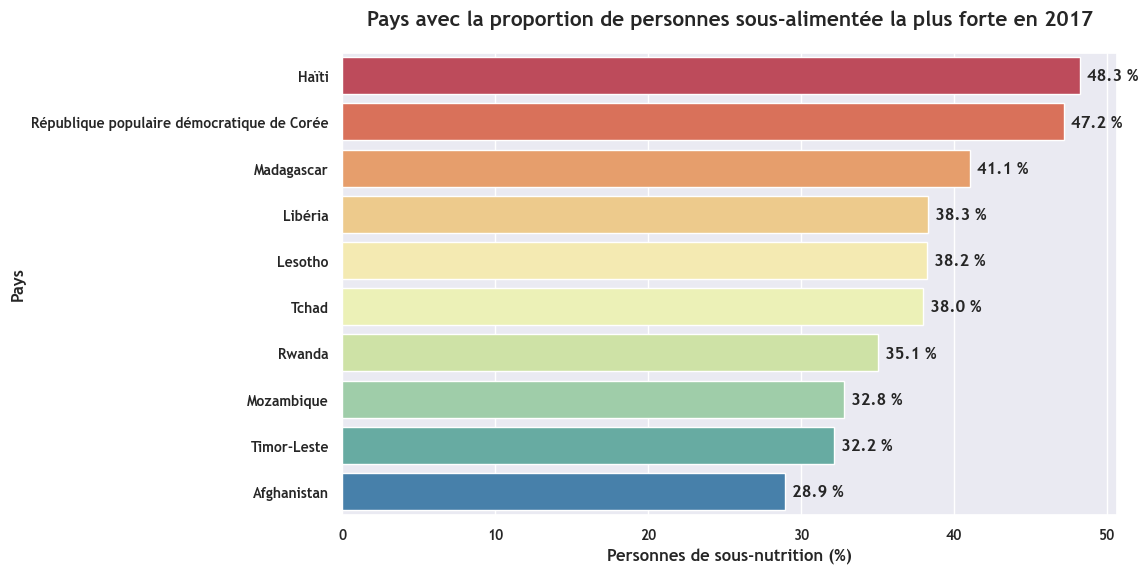

In [60]:
# graphique
makeBarplot(
    sous_nutrition_plus_forte,
    x='proportion',
    xLabel='Personnes de sous-nutrition (%)',
    y='Zone',
    yLabel='Pays',
    title='Pays avec la proportion de personnes sous-alimentée la plus forte en 2017',
    palette='Spectral',
    bar_label_format="%.1f %%"
)
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7 - Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013</h3>
</div>

In [61]:
#calcul du total de l'aide alimentaire par pays
aide_alimentaire_par_pays = aide_alimentaire.loc[aide_alimentaire['Année'] >= 2013]
aide_alimentaire_par_pays = aide_alimentaire_par_pays.groupby('Zone')['Valeur'].sum()

In [62]:
#affichage après trie des 10 pays qui ont bénéficié le plus de l'aide alimentaire
aide_alimentaire_par_pays = aide_alimentaire_par_pays.sort_values(ascending=False).head(10)

/var/folders/l2/wxdjr68x4hjf3wqj0ww37d9r0000gn/T/ipykernel_16305/1804943040.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  graph = sns.barplot(data=data, x=x, y=y, palette=palette)


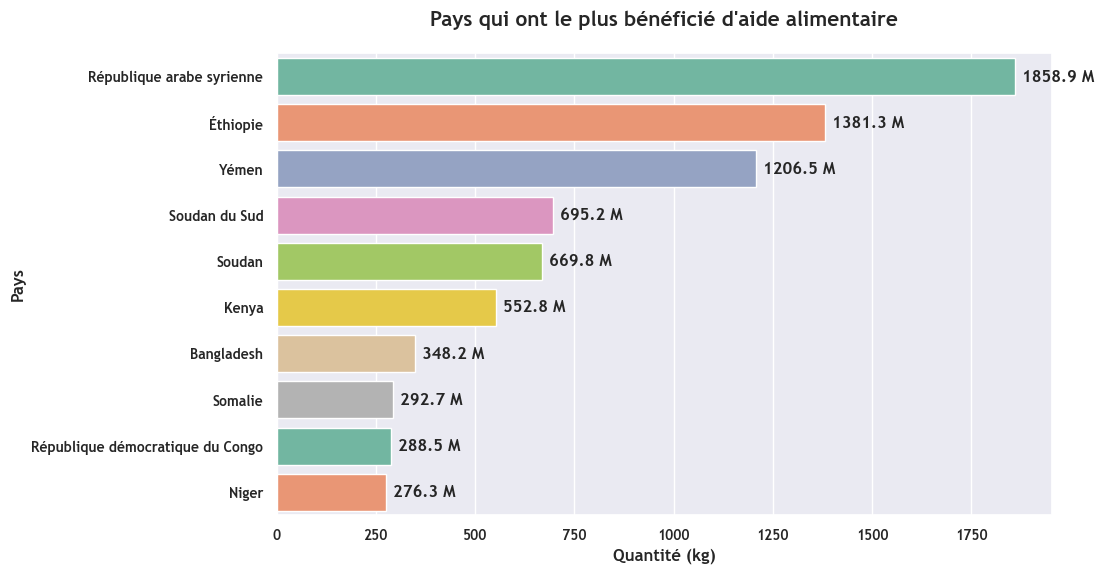

In [63]:
# graphique
aide_alimentaire_par_pays_graph = aide_alimentaire_par_pays.reset_index()
aide_alimentaire_par_pays_graph['Valeur'] = aide_alimentaire_par_pays_graph['Valeur'] / 1e6

makeBarplot(
    aide_alimentaire_par_pays_graph, 
    x='Valeur', 
    xLabel='Quantité (kg)', 
    y='Zone', 
    yLabel='Pays',
    bar_label_format="%.1f M",
    title="Pays qui ont le plus bénéficié d'aide alimentaire",
    palette='Set2'
)
plt.show()


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.8 - Evolution des 5 pays qui ont le plus bénéficiés de l'aide alimentaire entre 2013 et 2016</h3>
</div>

In [64]:
#Création d'un dataframe avec la zone, l'année et l'aide alimentaire puis groupby sur zone et année 
aide_alimentaire_evolution = aide_alimentaire[['Zone', 'Année', 'Valeur']]
aide_alimentaire_evolution = aide_alimentaire_evolution.groupby(['Zone', 'Année'])['Valeur'].sum()

In [65]:
#Création d'une liste contenant les 5 pays qui ont le plus bénéficiées de l'aide alimentaire
liste_pays_plus_beneficiees = aide_alimentaire_par_pays.reset_index()['Zone'][:5]

In [66]:
#On filtre sur le dataframe avec notre liste
aide_alimentaire_evolution = aide_alimentaire_evolution.reset_index()
aide_alimentaire_evolution = aide_alimentaire_evolution.loc[aide_alimentaire_evolution['Zone'].isin(liste_pays_plus_beneficiees)]

In [67]:
# Affichage des pays avec l'aide alimentaire par année
aide_alimentaire_evolution[['Zone', 'Année', 'Valeur']].sort_values(['Zone', 'Année'])

,Zone,Année,Valeur
157,République arabe syrienne,2013,563566000
158,République arabe syrienne,2014,651870000
159,République arabe syrienne,2015,524949000
160,République arabe syrienne,2016,118558000
189,Soudan,2013,330230000
190,Soudan,2014,321904000
191,Soudan,2015,17650000
192,Soudan du Sud,2013,196330000
193,Soudan du Sud,2014,450610000
194,Soudan du Sud,2015,48308000


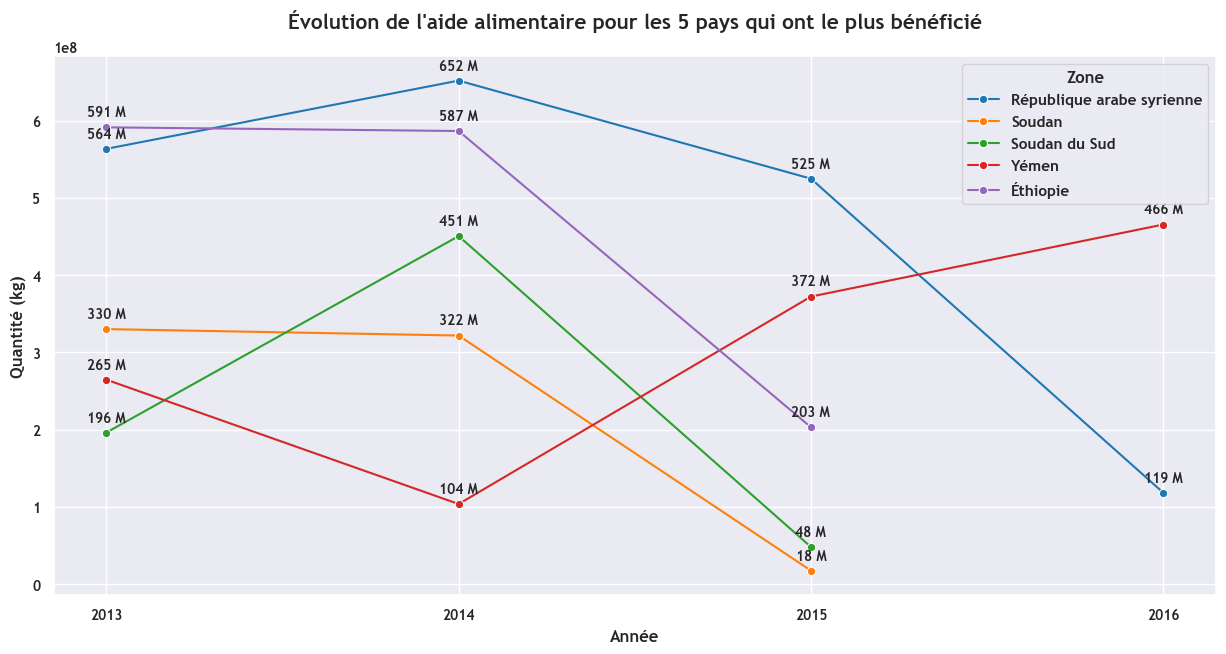

In [ ]:
# graphique
aide_alimentaire_evolution_graph = aide_alimentaire_evolution[['Zone', 'Année', 'Valeur']].sort_values(['Zone', 'Année'])

plt.figure(figsize=(15, 7))
plt.xticks(aide_alimentaire_evolution_graph['Année'].unique())

graph = sns.lineplot(
    aide_alimentaire_evolution_graph, 
    x='Année', 
    y='Valeur', 
    hue='Zone', 
    marker='o', 
    palette='tab10'
)

# Create small marker labels
for x, y in zip(aide_alimentaire_evolution_graph['Année'], aide_alimentaire_evolution_graph['Valeur']):
    plt.text(x, y+1e7, f"{(y/1e6):.0f} M", ha='center', va='bottom', fontdict={'size': 10})

makeGraphAttribut(
    graph=graph, 
    xLabel='Année', 
    yLabel='Quantité (kg)', 
    title="Évolution de l'aide alimentaire pour les 5 pays qui ont le plus bénéficié"
)
plt.show()

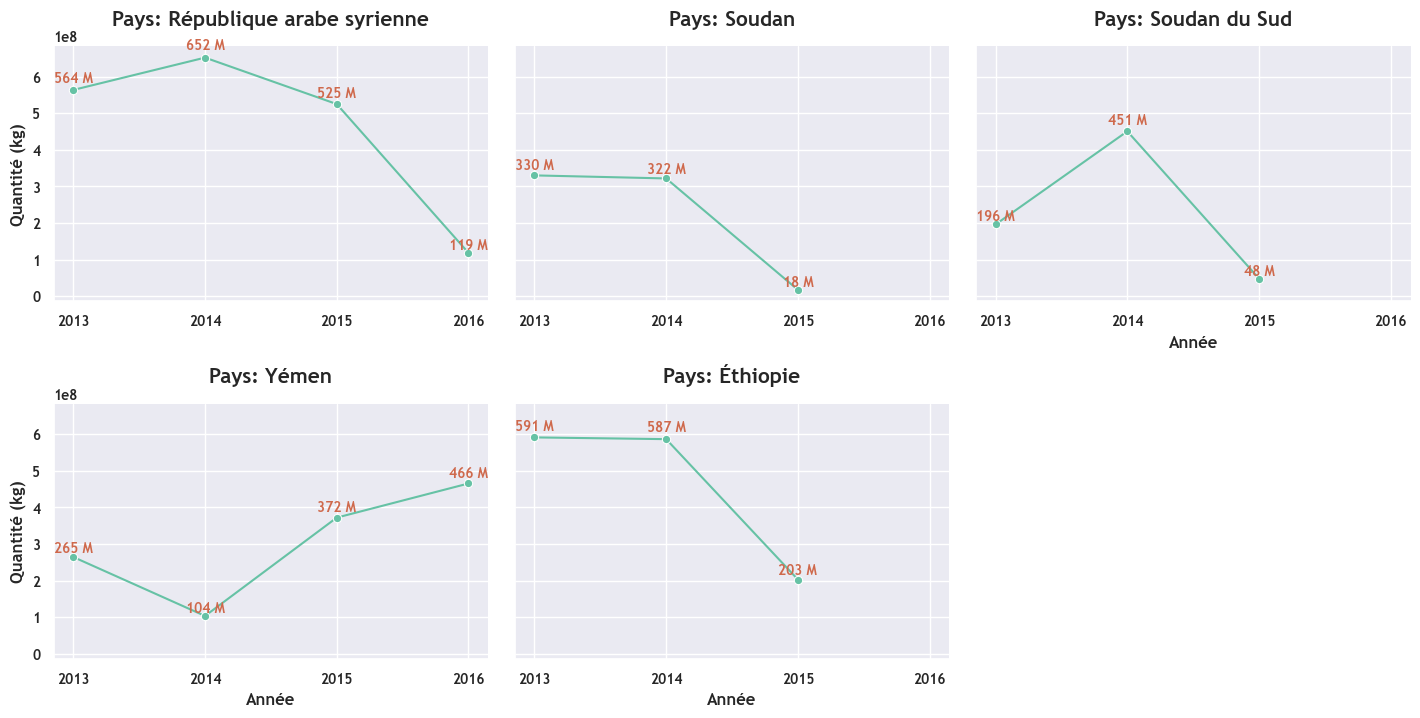

In [ ]:
# graphique (FacetGrid)
aide_years = sorted(aide_alimentaire_evolution_graph['Année'].unique().astype(int))

g = sns.FacetGrid(
    aide_alimentaire_evolution_graph,
    col='Zone',
    height=4,
    col_wrap=3,
    aspect=1.2,
    margin_titles=True
)
g.map(
    sns.lineplot, 
    'Année', 
    'Valeur',
    marker="o"
)

g.set_axis_labels(y_var='Quantité (kg)')
g.set_titles(col_template="Pays: {col_name}")
g.figure.subplots_adjust(hspace=0.4, top=0.85)

# make labels on markers
for ax in g.axes.flat:
    ax.set_xticks(aide_years)
    ax.tick_params(axis='x', labelbottom=True)  # force to show xticks
    ax.set_title(ax.get_title(), pad=15)

    for line in ax.lines:
        x_data = line.get_xdata()
        y_data = line.get_ydata()

        for x, y in zip(x_data, y_data):
            ax.text(
                x,
                y * 1.02,
                f"{(y/1e6):.0f} M",
                ha='center',
                va='bottom',
                fontsize=10,
                color='#cf694c'
            )
plt.show()

In [70]:
# préparer la table : sous_nutrition_avec_annee
sous_nutrition_avec_annee = sous_nutrition.copy()
sous_nutrition_avec_annee[['start', 'end']] = sous_nutrition_avec_annee['Année'].str.split('-', expand=True).astype(int)
sous_nutrition_avec_annee['annee_moyenne'] = ((sous_nutrition_avec_annee.start + sous_nutrition_avec_annee.end) / 2).astype(int)

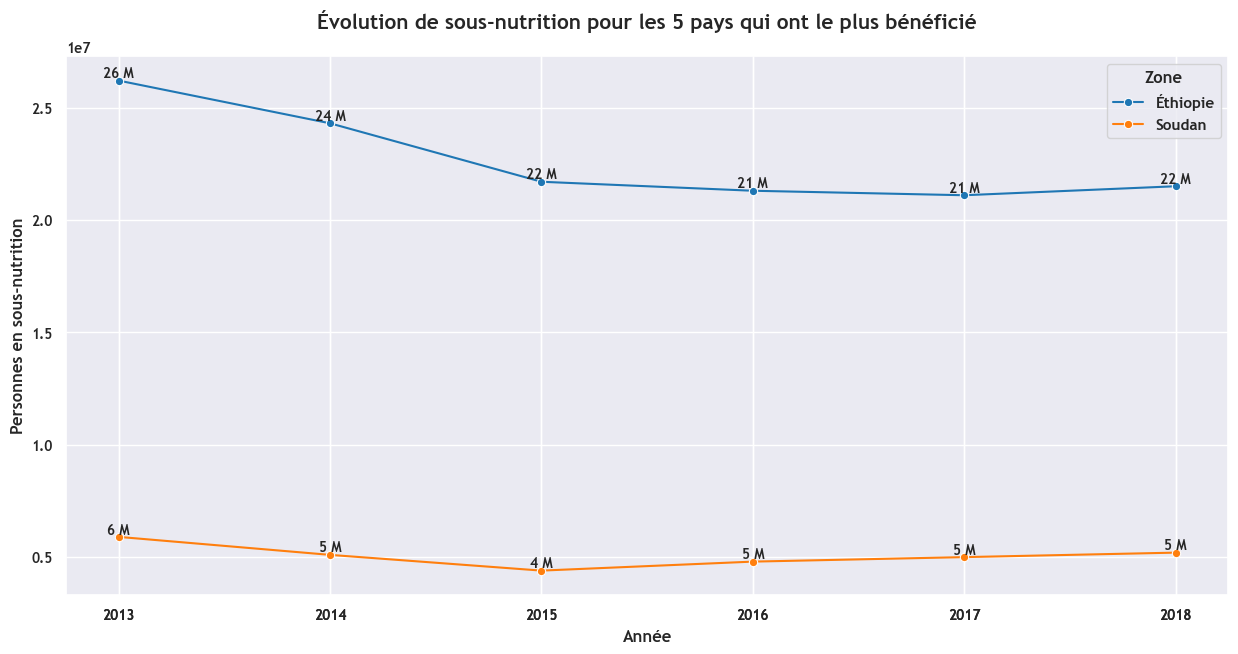

In [ ]:
# graphique : Évolution de sous-nutrition pour les 5 pays qui ont le plus bénéficié (seulement Éthiopie et Soudan ont des donnée sur sous-nutrition)

aide_top5_pays = sous_nutrition_avec_annee.loc[(sous_nutrition_avec_annee['Zone'].isin(liste_pays_plus_beneficiees)) & (sous_nutrition_avec_annee['sous_nutrition'] > 0)]

plt.figure(figsize=(15, 7))
plt.xticks(aide_top5_pays['annee_moyenne'])

graph = sns.lineplot(
    aide_top5_pays, 
    x='annee_moyenne', 
    y='sous_nutrition', 
    hue='Zone', 
    marker='o', 
    palette='tab10'
)

# Create small marker labels
for x, y in zip(aide_top5_pays['annee_moyenne'], aide_top5_pays['sous_nutrition']):
    plt.text(x, y, f"{(y/1e6):.0f} M", ha='center', va='bottom', fontdict={'size': 10})

makeGraphAttribut(
    graph=graph, 
    xLabel='Année', 
    yLabel='Personnes en sous-nutrition', 
    title="Évolution de sous-nutrition pour les 5 pays qui ont le plus bénéficié"
)
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.9 - Pays avec le moins de disponibilité par habitant</h3>
</div>

In [72]:
#Calcul de la disponibilité en kcal par personne par jour par pays
kcal_par_personne_par_jour_par_pays = population_dispo_alimentaire.groupby('Zone').agg({'Disponibilité alimentaire (Kcal/personne/jour)': 'sum'})

In [73]:
#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne 
kcal_par_personne_par_jour_par_pays.sort_values('Disponibilité alimentaire (Kcal/personne/jour)').head(10)

,Disponibilité alimentaire (Kcal/personne/jour)
Zone,
République centrafricaine,1879.0
Zambie,1924.0
Madagascar,2056.0
Afghanistan,2087.0
Haïti,2089.0
République populaire démocratique de Corée,2093.0
Tchad,2109.0
Zimbabwe,2113.0
Ouganda,2126.0


/var/folders/l2/wxdjr68x4hjf3wqj0ww37d9r0000gn/T/ipykernel_16305/1804943040.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  graph = sns.barplot(data=data, x=x, y=y, palette=palette)


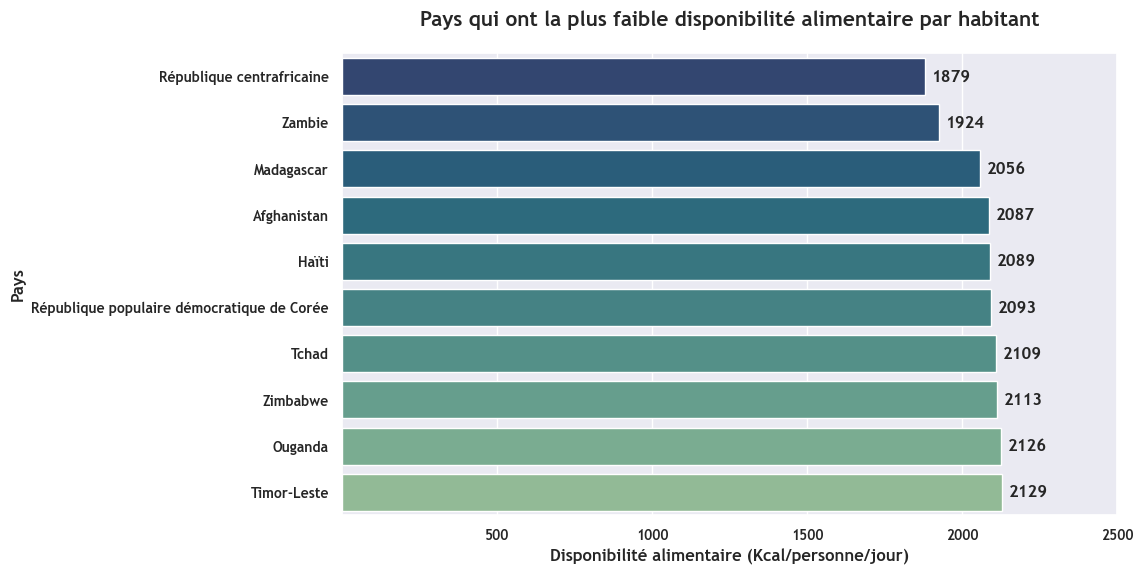

In [74]:
# graphique
pays_le_moins_dispo = kcal_par_personne_par_jour_par_pays.reset_index().sort_values('Disponibilité alimentaire (Kcal/personne/jour)').head(10)

makeBarplot(
    pays_le_moins_dispo,
    x='Disponibilité alimentaire (Kcal/personne/jour)',
    xLabel='Disponibilité alimentaire (Kcal/personne/jour)',
    y='Zone',
    yLabel='Pays',
    title='Pays qui ont la plus faible disponibilité alimentaire par habitant',
    palette='crest_r'
)
plt.xticks([500, 1000, 1500, 2000, 2500])
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10 - Pays avec le plus de disponibilité par habitant</h3>
</div>

In [75]:
#Affichage des 10 pays qui ont le plus de dispo alimentaire par personne 
kcal_par_personne_par_jour_par_pays.sort_values('Disponibilité alimentaire (Kcal/personne/jour)', ascending=False).head(10)

,Disponibilité alimentaire (Kcal/personne/jour)
Zone,
Autriche,3770.0
Belgique,3737.0
Turquie,3708.0
États-Unis d'Amérique,3682.0
Israël,3610.0
Irlande,3602.0
Italie,3578.0
Luxembourg,3540.0
Égypte,3518.0


/var/folders/l2/wxdjr68x4hjf3wqj0ww37d9r0000gn/T/ipykernel_16305/1804943040.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  graph = sns.barplot(data=data, x=x, y=y, palette=palette)


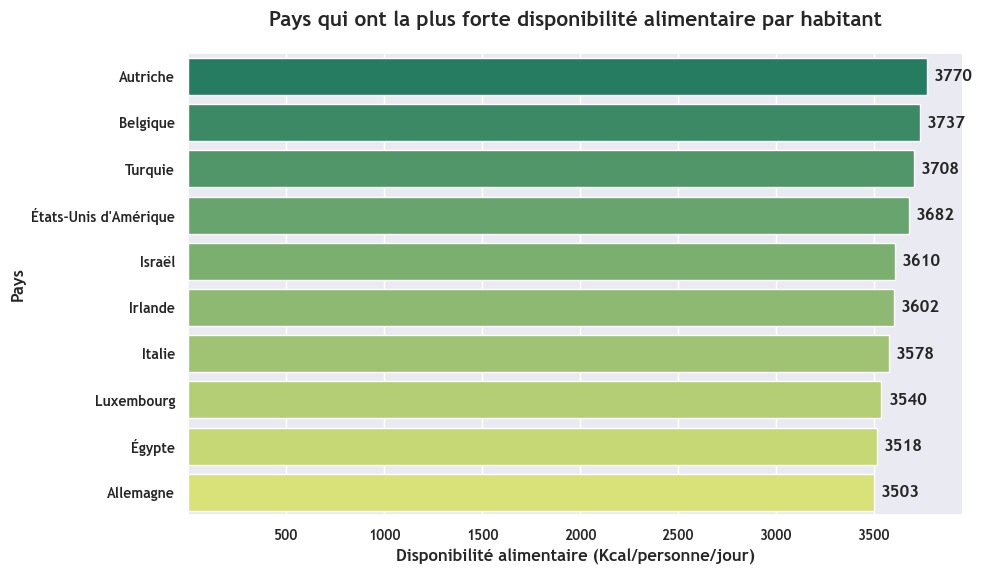

In [76]:
# graphique
pays_le_plus_dispo = kcal_par_personne_par_jour_par_pays.reset_index().sort_values('Disponibilité alimentaire (Kcal/personne/jour)', ascending=False).head(10)

makeBarplot(
    pays_le_plus_dispo,
    x='Disponibilité alimentaire (Kcal/personne/jour)',
    xLabel='Disponibilité alimentaire (Kcal/personne/jour)',
    y='Zone',
    yLabel='Pays',
    title='Pays qui ont la plus forte disponibilité alimentaire par habitant',
    palette='summer'
)
plt.xticks([500, 1000, 1500, 2000, 2500, 3000, 3500])
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.11 - Exemple de la Thaïlande pour le Manioc</h3>
</div>

In [77]:
# Proportion de Manioc (Thaïlande / Monde)
manioc_thai = dispo_alimentaire.loc[(dispo_alimentaire['Zone'] == 'Thaïlande') & (dispo_alimentaire['Produit'] == 'Manioc'), 'Production'].sum()
manioc_mondial = dispo_alimentaire.loc[dispo_alimentaire['Produit'] == 'Manioc']

part_manioc_mondial = manioc_mondial.groupby('Zone').agg({'Production': 'sum'})
total_manioc_mondial = part_manioc_mondial['Production'].sum()

part_manioc_mondial['Proportion'] = part_manioc_mondial['Production'] / total_manioc_mondial * 100

part_manioc_mondial = part_manioc_mondial.sort_values('Proportion', ascending=False).head(10)

/var/folders/l2/wxdjr68x4hjf3wqj0ww37d9r0000gn/T/ipykernel_16305/1804943040.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  graph = sns.barplot(data=data, x=x, y=y, palette=palette)


<Axes: title={'center': 'Proportion de la production de Manioc'}, xlabel='Pourcentage', ylabel='Pays'>

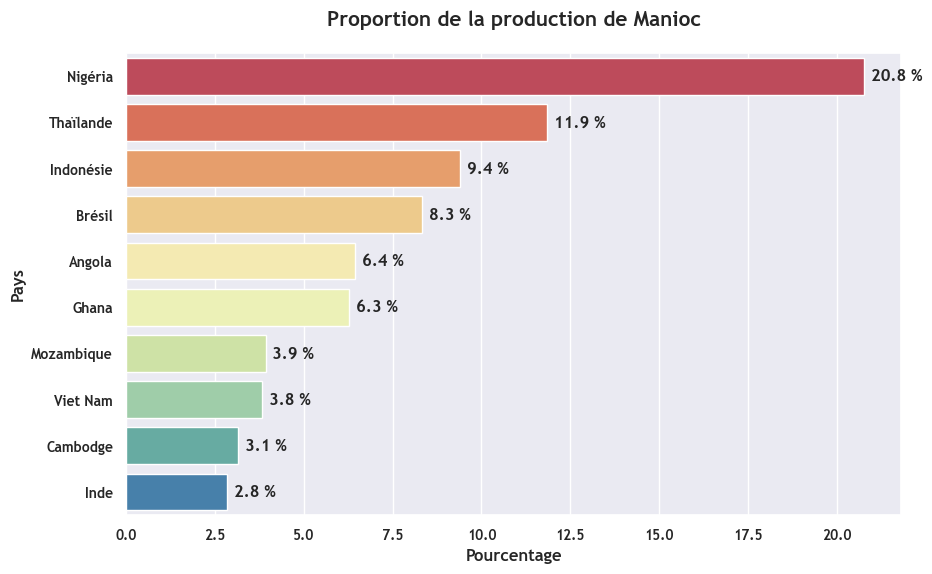

In [ ]:
# graphique: Proportion de Manioc (Thaïlande / Monde)
makeBarplot(
    part_manioc_mondial,
    x='Proportion',
    xLabel='Pourcentage',
    y=part_manioc_mondial.index,
    yLabel='Pays',
    title="Proportion de la production de Manioc",
    bar_label_format="%.1f %%"
)
plt.show()

In [79]:
#création d'un dataframe avec uniquement la Thaïlande 
dispo_alimentaire_thailande = population_dispo_alimentaire[population_dispo_alimentaire['Zone'] == 'Thaïlande']
sous_nutrition_2017_thailande = sous_nutrition_2017[sous_nutrition_2017['Zone'] == 'Thaïlande']
data_thailande = pd.merge(dispo_alimentaire_thailande, sous_nutrition_2017_thailande, on='Zone', how='left')
data_thailande

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,...,Semences,Traitement,Variation de stock,Année_x,Population,dispo_kcal,Année_y,sous_nutrition,debut_annee,fin_annee
0,Thaïlande,Abats Comestible,animale,0.0,0.0,3.0,1.11,0.09,0.56,74000000.0,...,0.0,0.0,0.0,2017.0,69209810.0,2.076294e+08,2016-2018,6200000.0,2016,2018
1,Thaïlande,"Agrumes, Autres",vegetale,0.0,0.0,0.0,0.09,0.00,0.00,8000000.0,...,0.0,2000000.0,0.0,2017.0,69209810.0,0.000000e+00,2016-2018,6200000.0,2016,2018
2,Thaïlande,"Alcool, non Comestible",vegetale,0.0,358000000.0,0.0,0.00,0.00,0.00,358000000.0,...,0.0,0.0,0.0,2017.0,69209810.0,0.000000e+00,2016-2018,6200000.0,2016,2018
3,Thaïlande,Aliments pour enfants,vegetale,0.0,0.0,2.0,0.18,0.01,0.08,12000000.0,...,0.0,0.0,0.0,2017.0,69209810.0,1.384196e+08,2016-2018,6200000.0,2016,2018
4,Thaïlande,Ananas,vegetale,0.0,0.0,10.0,10.02,0.04,0.08,782000000.0,...,0.0,0.0,13.0,2017.0,69209810.0,6.920981e+08,2016-2018,6200000.0,2016,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,Thaïlande,Viande de Suides,animale,0.0,0.0,124.0,13.00,11.83,3.92,871000000.0,...,0.0,0.0,0.0,2017.0,69209810.0,8.582016e+09,2016-2018,6200000.0,2016,2018
91,Thaïlande,Viande de Volailles,animale,0.0,0.0,52.0,13.69,3.62,4.49,945000000.0,...,0.0,0.0,0.0,2017.0,69209810.0,3.598910e+09,2016-2018,6200000.0,2016,2018
92,Thaïlande,"Viande, Autre",animale,0.0,0.0,0.0,0.03,0.01,0.02,-92000000.0,...,0.0,0.0,0.0,2017.0,69209810.0,0.000000e+00,2016-2018,6200000.0,2016,2018
93,Thaïlande,Vin,vegetale,0.0,0.0,0.0,0.12,0.00,0.00,8000000.0,...,0.0,0.0,0.0,2017.0,69209810.0,0.000000e+00,2016-2018,6200000.0,2016,2018


In [80]:
#Calcul de la sous nutrition en Thaïlande
sous_nutrition_proportion_thailande = data_thailande['sous_nutrition'][0] / data_thailande['Population'][0] * 100
print(f"La sous nutrition en Thaïlande: {int(data_thailande['sous_nutrition'][0])} personnes, {round(sous_nutrition_proportion_thailande, 2)} %")

La sous nutrition en Thaïlande: 6200000 personnes, 8.96 %


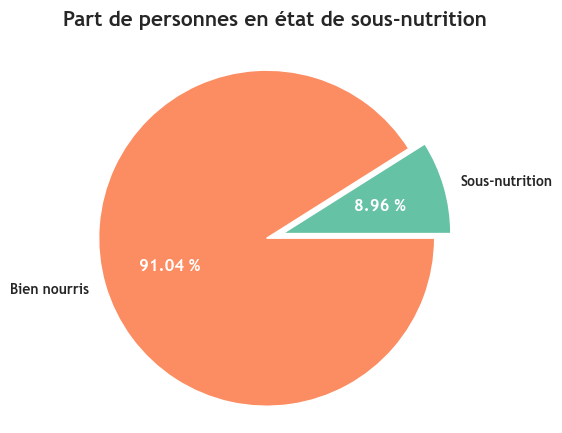

In [81]:
# graphique
list_data = [data_thailande['sous_nutrition'][0], (data_thailande['Population'][0] - data_thailande['sous_nutrition'][0])]
explode = tuple(np.full(len(list_data), 0.05))

wedges, label_texts, pct_texts = plt.pie(
    list_data, 
    labels=['Sous-nutrition', 'Bien nourris'], 
    autopct="%.2f %%",
    explode=explode
)

makePctLabel(pct_texts)
makeTitle("Part de personnes en état de sous-nutrition")
plt.axis('equal')
sns.set_palette('Spectral')
plt.show()

In [82]:
# On calcule la proportion exportée en fonction de la proportion
proportion_exportee = data_thailande.groupby('Zone').agg({'Production': 'sum', 'Exportations - Quantité': 'sum'})
proportion_exportee_calcul = (proportion_exportee['Exportations - Quantité'] / proportion_exportee['Production'] * 100).iloc[0]

print(f"La proportion exportée en Thaïlande: {proportion_exportee_calcul.round(2)} %")

La proportion exportée en Thaïlande: 24.99 %


In [83]:
# proportion de produits
part_produit_thai = data_thailande.groupby('Produit')[['Production', 'Exportations - Quantité']].sum()

part_produit_thai['Reste de la production'] = part_produit_thai['Production'] - part_produit_thai['Exportations - Quantité']
part_produit_thai['Reste de la production (%)'] = (part_produit_thai['Reste de la production'] / part_produit_thai['Production'] * 100).round(2)

part_produit_thai = part_produit_thai.sort_values('Production', ascending=False).head(10)

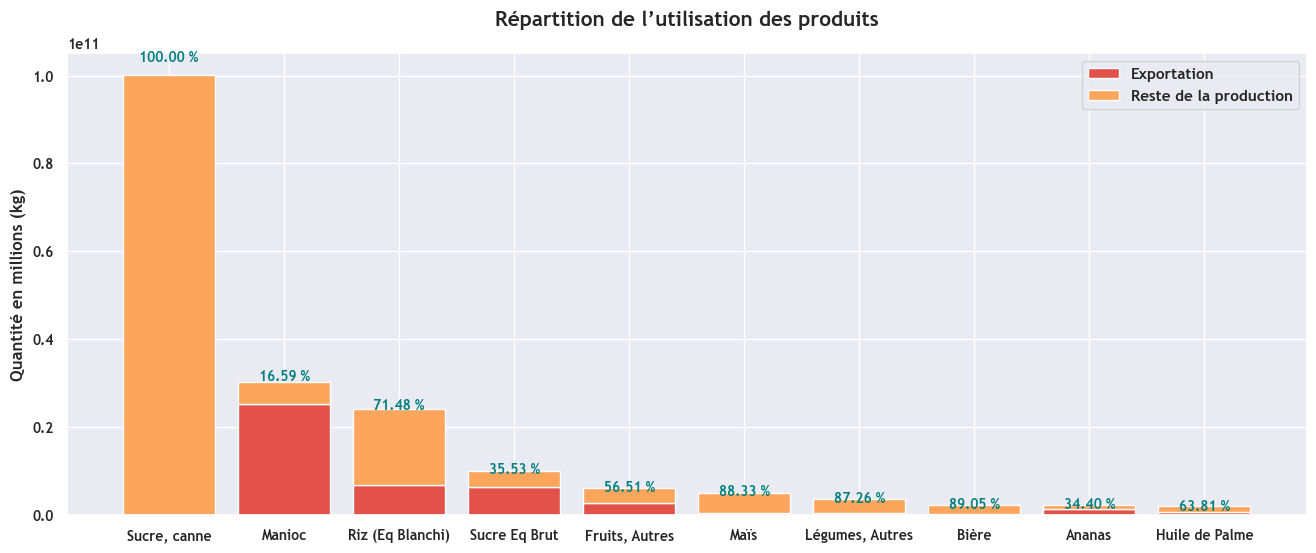

In [84]:
# graphique
fig, ax = plt.subplots(figsize=(16, 6))

ax.bar(
    part_produit_thai.index,
    part_produit_thai['Exportations - Quantité'],
    label='Exportation'
)

ax.bar(
    part_produit_thai.index,
    part_produit_thai['Reste de la production'],
    bottom=part_produit_thai['Exportations - Quantité'],
    label='Reste de la production'
)

makeTitle("Répartition de l’utilisation des produits")
ax.set_ylabel("Quantité en millions (kg)", fontweight='bold', fontsize=12)
ax.legend()
sns.set_palette('Set2')

# make labels
for i, produit in enumerate(part_produit_thai.index):
    y_position = (
        part_produit_thai.loc[produit, 'Production'] * 1.04
    )

    ax.text(
        i,
        y_position,
        f"{part_produit_thai.loc[produit, 'Reste de la production (%)']:.2f} %",
        ha='center',
        va='center',
        color='teal',
        fontweight='bold',
        fontsize=10
    )
plt.show()

/var/folders/l2/wxdjr68x4hjf3wqj0ww37d9r0000gn/T/ipykernel_16305/1804943040.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  graph = sns.barplot(data=data, x=x, y=y, palette=palette)


<Axes: title={'center': 'Part du reste de la production'}, xlabel='Production - Exportation', ylabel='Produit'>

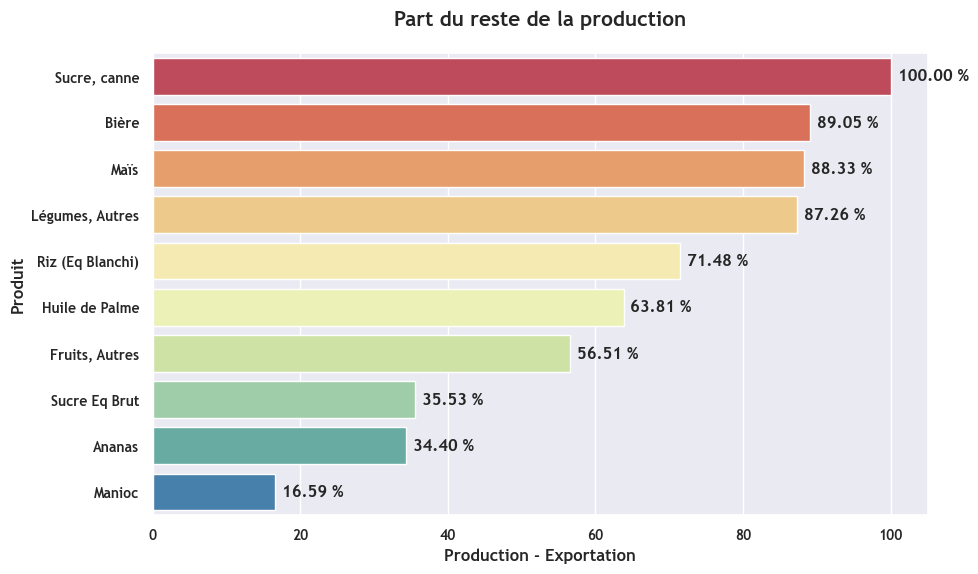

In [ ]:
# graphique: top 10 produits les plus (Production - Exportation)
part_produit_thai_top10 = part_produit_thai.sort_values('Reste de la production (%)', ascending=False)
makeBarplot(
    part_produit_thai_top10,
    x='Reste de la production (%)',
    xLabel='Production - Exportation',
    y='Produit',
    yLabel='Produit',
    title='Part du reste de la production',
    bar_label_format="%.2f %%"
)
plt.show()

In [86]:
# On calcule la proportion exportée de manioc
proportion_exportee_manioc = data_thailande.loc[data_thailande['Produit'] == 'Manioc']
proportion_exportee_manioc = proportion_exportee_manioc.groupby('Zone').agg({'Production': 'sum', 'Exportations - Quantité': 'sum'})
proportion_exportee_manioc_calcul = (proportion_exportee_manioc['Exportations - Quantité'] / proportion_exportee_manioc['Production'] * 100).iloc[0]

print(f"La proportion exportée de Manioc en Thaïlande: {proportion_exportee_manioc_calcul.round(2)} %")

La proportion exportée de Manioc en Thaïlande: 83.41 %


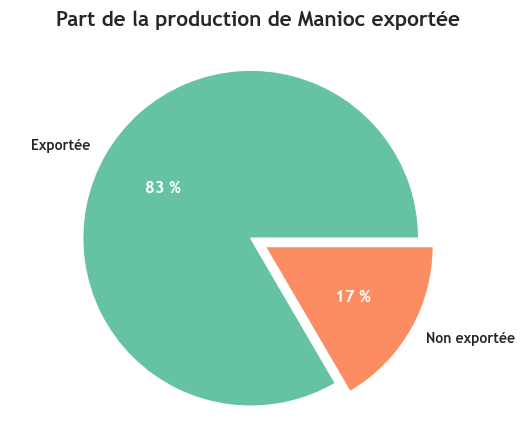

In [87]:
# graphique
exportee_manioc_total = proportion_exportee_manioc['Exportations - Quantité'].iloc[0]
production_manioc_total = proportion_exportee_manioc['Production'].iloc[0]

graph_list = [exportee_manioc_total, (production_manioc_total - exportee_manioc_total)]
explode = tuple(np.full(len(graph_list), 0.05))

wedges, label_texts, pct_texts = plt.pie(
    graph_list, 
    labels=['Exportée', 'Non exportée'], 
    autopct="%.0f %%",
    explode=explode
)

makePctLabel(pct_texts)
makeTitle("Part de la production de Manioc exportée")
plt.axis('equal')
plt.show()

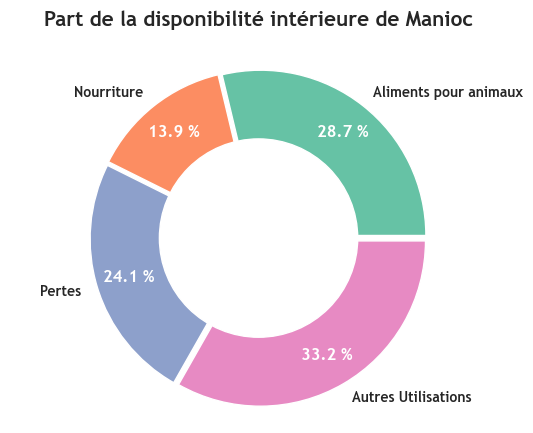

In [88]:
# graphique: la part d'usage intérieur de manioc

part_dispo_interieur_manioc = data_thailande.loc[data_thailande['Produit'] == 'Manioc']

# Semences and Traitement are 0.0 -> no use
part_manioc_cols = ['Aliments pour animaux', 'Nourriture', 'Pertes', 'Autres Utilisations']

explode = tuple(np.full(len(part_manioc_cols), 0.02))
part_dispo_interieur_manioc = part_dispo_interieur_manioc[part_manioc_cols]

wedges, label_texts, pct_texts = plt.pie(
    part_dispo_interieur_manioc.iloc[0], 
    labels=part_manioc_cols, 
    autopct="%.1f %%",
    pctdistance=0.8,
    explode=explode
)

# draw circle
centre_circle = plt.Circle((0, 0), 0.60, fc='white')
fig = plt.gcf()

# Adding Circle in Pie chart
fig.gca().add_artist(centre_circle)

makePctLabel(pct_texts)
makeTitle("Part de la disponibilité intérieure de Manioc")
plt.axis('equal')
sns.set_palette('Set2')
plt.show()

In [89]:
# la disponibilité par habitant pour la Thaïlande
dispo_par_personne_thai = data_thailande['Disponibilité alimentaire (Kcal/personne/jour)'].sum()
dispo_par_personne_thai

np.float64(2785.0)

In [90]:
# Disponibilité de manioc (kg/personne/an)
dispo_par_personne_manioc = data_thailande.loc[data_thailande['Produit'] == 'Manioc']
dispo_manioc_par_personne_par_an = round((dispo_par_personne_manioc['Production'] - dispo_par_personne_manioc['Exportations - Quantité']) / dispo_par_personne_manioc['Population'], 2)

print(f"Disponibilité de manioc en quantité (kg/personne/an): {dispo_par_personne_manioc['Disponibilité alimentaire en quantité (kg/personne/an)'].iloc[0]}")
print(f"Disponibilité de manioc théorique en quantité (kg/personne/an): {dispo_manioc_par_personne_par_an.iloc[0]}")

Disponibilité de manioc en quantité (kg/personne/an): 13.0
Disponibilité de manioc théorique en quantité (kg/personne/an): 72.45


In [91]:
dispo_manioc_theorique = pd.DataFrame()
dispo_manioc_theorique['Categorie'] = ['Disponibilité réelle', 'Disponibilité théorique']
dispo_manioc_theorique['Value'] = [dispo_par_personne_manioc['Disponibilité alimentaire en quantité (kg/personne/an)'].iloc[0], dispo_manioc_par_personne_par_an.iloc[0]]

dispo_manioc_theorique

,Categorie,Value
0,Disponibilité réelle,13.00
1,Disponibilité théorique,72.45


/var/folders/l2/wxdjr68x4hjf3wqj0ww37d9r0000gn/T/ipykernel_16305/1804943040.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  graph = sns.barplot(data=data, x=x, y=y, palette=palette)


<Axes: title={'center': 'Disponibilité de manioc'}, ylabel='Quantité (kg/personne/an)'>

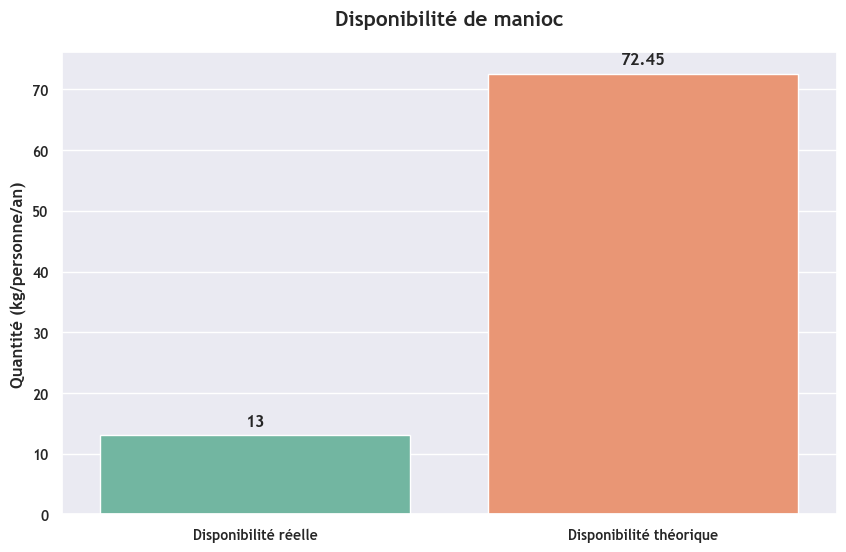

In [ ]:
# graphique: Disponibilité réelle vs. théorique de manioc (kg/personne/an)
list_data = [dispo_par_personne_manioc['Disponibilité alimentaire en quantité (kg/personne/an)'].iloc[0], dispo_manioc_par_personne_par_an.iloc[0]]


makeBarplot(
    dispo_manioc_theorique,
    x='Categorie',
    xLabel='',
    y='Value',
    yLabel="Quantité (kg/personne/an)",
    title="Disponibilité de manioc",
    palette='Set2'
)
plt.show()

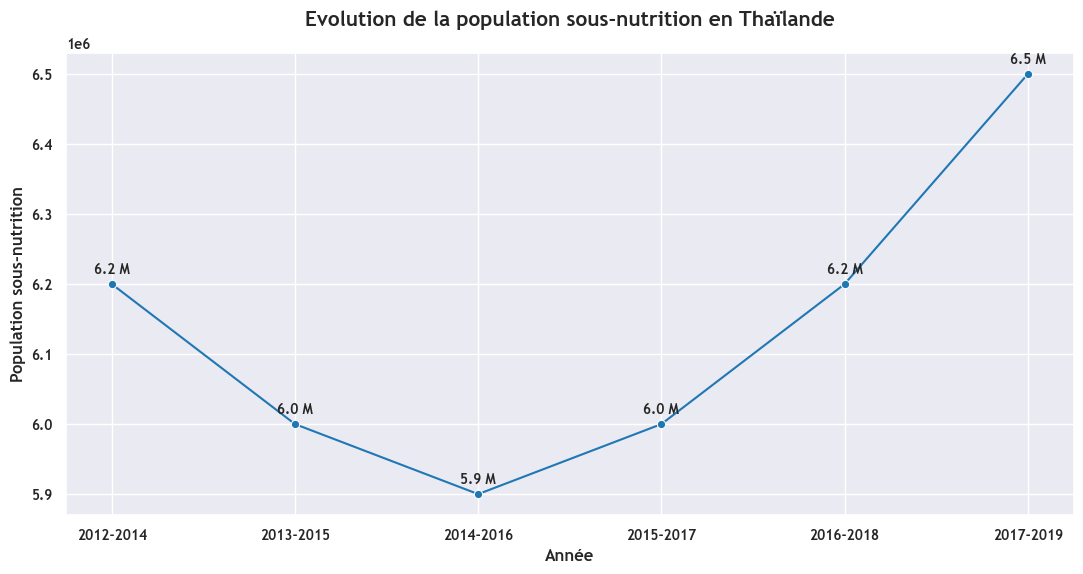

In [ ]:
# graphique : evolution de sous-nutrition
sous_nutrition_thai = sous_nutrition.loc[sous_nutrition['Zone'] == 'Thaïlande']
sous_nutrition_thai

plt.figure(figsize=(13, 6))

graph = sns.lineplot(
    sous_nutrition_thai, 
    x='Année', 
    y='sous_nutrition', 
    marker='o', 
    hue='Zone',
    palette='tab10',
    legend=False
)

# Create small marker labels
for x, y in zip(sous_nutrition_thai['Année'], sous_nutrition_thai['sous_nutrition']):
    plt.text(x, y+1e4, f"{(y/1e6):.1f} M", ha='center', va='bottom', fontdict={'size': 10})

makeGraphAttribut(
    graph=graph, 
    xLabel='Année', 
    yLabel='Population sous-nutrition', 
    title="Evolution de la population sous-nutrition en Thaïlande"
)
plt.show()

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Analyse complémentaires</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.12 - Relation entre la disponibilité alimentaire et la sous-nutrition</h3>
</div>

In [94]:
# Disponibilité alimentaire en quantité (kg/personne/an) par pays

dispo_haut = dispo_alimentaire.groupby('Zone').agg({'Disponibilité alimentaire en quantité (kg/personne/an)': 'sum'})
dispo_haut['Disponibilité alimentaire en quantité (kg/personne/an)'].describe()
# 50% : 672.10
# mean : 702.31

count     174.000000
mean      702.310000
std       206.182832
min       319.450000
25%       545.187500
50%       672.100000
75%       863.400000
max      1210.410000
Name: Disponibilité alimentaire en quantité (kg/personne/an), dtype: float64

In [95]:
dispo_haut.sort_values('Disponibilité alimentaire en quantité (kg/personne/an)', ascending=False).head(10)

,Disponibilité alimentaire en quantité (kg/personne/an)
Zone,
Monténégro,1210.41
Luxembourg,1150.66
Irlande,1150.15
Albanie,1095.54
Finlande,1093.77
Grèce,1070.90
Pays-Bas,1069.22
Autriche,1069.20
Lituanie,1050.07


In [99]:
population_sous_nutrition_2017.sort_values('proportion', ascending=False).head(10)

,Zone,Année_x,Population,Année_y,sous_nutrition,debut_annee,fin_annee,proportion,proportion_sous_nutrition_str
78,Haïti,2017,10982366.0,2016-2018,5300000,2016,2018,48.26,48.26 %
157,République populaire démocratique de Corée,2017,25429825.0,2016-2018,12000000,2016,2018,47.19,47.19 %
108,Madagascar,2017,25570512.0,2016-2018,10500000,2016,2018,41.06,41.06 %
103,Libéria,2017,4702226.0,2016-2018,1800000,2016,2018,38.28,38.28 %
100,Lesotho,2017,2091534.0,2016-2018,800000,2016,2018,38.25,38.25 %
183,Tchad,2017,15016753.0,2016-2018,5700000,2016,2018,37.96,37.96 %
161,Rwanda,2017,11980961.0,2016-2018,4200000,2016,2018,35.06,35.06 %
121,Mozambique,2017,28649018.0,2016-2018,9400000,2016,2018,32.81,32.81 %
186,Timor-Leste,2017,1243258.0,2016-2018,400000,2016,2018,32.17,32.17 %
0,Afghanistan,2017,36296113.0,2016-2018,10500000,2016,2018,28.93,28.93 %


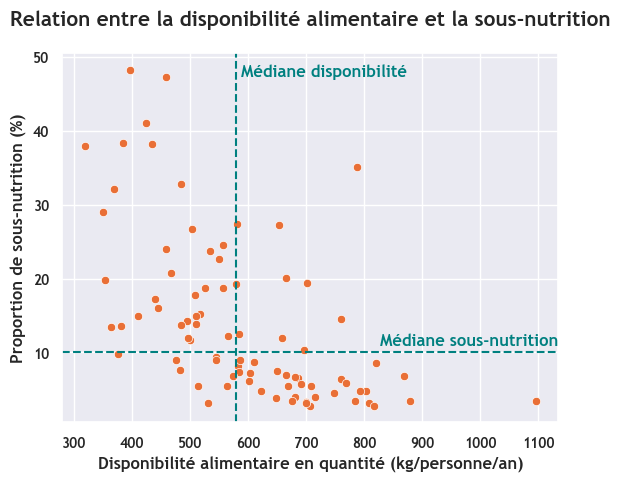

In [100]:
scatter_dispo_sous_nutrition = pd.merge(left=population_sous_nutrition_2017, right=dispo_haut, on='Zone', how='left')
scatter_dispo_sous_nutrition = scatter_dispo_sous_nutrition.loc[scatter_dispo_sous_nutrition['proportion'] > 0]

x_median = scatter_dispo_sous_nutrition['Disponibilité alimentaire en quantité (kg/personne/an)'].median()
y_median = scatter_dispo_sous_nutrition['proportion'].median()

ax = sns.scatterplot(
    scatter_dispo_sous_nutrition,
    x='Disponibilité alimentaire en quantité (kg/personne/an)',
    y='proportion'
)
ax.axvline(x=x_median, linestyle="--", color="teal")
ax.axhline(y=y_median, linestyle="--", color="teal")

ax.text(
    x_median, 
    ax.get_ylim()[1] * 0.97,
    " Médiane disponibilité",
    va="top",
    color="teal"
)

ax.text(
    ax.get_xlim()[1], 
    y_median * 1.1,
    " Médiane sous-nutrition",
    ha="right", 
    color="teal"
)
sns.set_palette('icefire_r')
ax.set_ylabel("Proportion de sous-nutrition (%)")
makeTitle("Relation entre la disponibilité alimentaire et la sous-nutrition")
plt.show()